# Mutual Fund Performance Analysis
Analysing 68 funds from the Moneycontrol screener export.  
Goals:
- Identify funds with **high 10-year returns** *and* **stable performance** across all time frames
- Visualise distribution by **Category**, **Crisil Rating**, and **AUM**

## 1. Import Required Libraries

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from pathlib import Path

# ── aesthetics ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi": 130,
    "figure.facecolor": "#0d1117",
    "axes.facecolor": "#0d1117",
    "axes.edgecolor": "#30363d",
    "axes.labelcolor": "#c9d1d9",
    "text.color": "#c9d1d9",
    "xtick.color": "#c9d1d9",
    "ytick.color": "#c9d1d9",
    "grid.color": "#21262d",
    "legend.facecolor": "#161b22",
    "legend.edgecolor": "#30363d",
})

PALETTE = [
    "#58a6ff","#3fb950","#f78166","#d2a8ff","#ffa657",
    "#79c0ff","#56d364","#ff7b72","#bc8cff","#e3b341",
    "#1f6feb","#238636",
]
print("Libraries loaded ✓")

Libraries loaded ✓


## 2. Load and Inspect the Data

In [11]:
TSV_PATH = Path("../mutualfunds/top_funds_moneycontrol.tsv")
df = pd.read_csv(TSV_PATH, sep="\t")

# ── numeric coercion ─────────────────────────────────────────────────────────
RETURN_COLS = ["1W", "1M", "3M", "6M", "YTD", "1Y", "2Y", "3Y", "5Y", "10Y"]

# returns are stored as "32%" strings — strip % and convert to float
for c in RETURN_COLS:
    df[c] = pd.to_numeric(
        df[c].astype(str).str.replace("%", "", regex=False).str.strip(),
        errors="coerce"
    )

df["AuM (Cr)"]      = pd.to_numeric(df["AuM (Cr)"], errors="coerce")
df["Crisil Rating"] = pd.to_numeric(df["Crisil Rating"], errors="coerce")

# ── short readable name ──────────────────────────────────────────────────────
df["Short Name"] = (
    df["Scheme Name"]
    .str.replace(r" - Direct Plan.*", "", regex=True)
    .str.replace(r" - Growth.*", "", regex=True)
    .str.strip()
)

print(f"Dataset: {df.shape[0]} funds × {df.shape[1]} columns")
print(f"\nReturn columns  : {RETURN_COLS}")
print(f"Categories      : {sorted(df['Category Name'].unique())}")
print(f"Crisil Ratings  : {sorted(df['Crisil Rating'].dropna().unique())}")
print(f"AuM range (Cr)  : {df['AuM (Cr)'].min():,.0f} – {df['AuM (Cr)'].max():,.0f}")
df.head()


Dataset: 68 funds × 16 columns

Return columns  : ['1W', '1M', '3M', '6M', 'YTD', '1Y', '2Y', '3Y', '5Y', '10Y']
Categories      : ['Contra Fund', 'ELSS', 'Flexi Cap Fund', 'Focused Fund', 'Large & Mid Cap Fund', 'Large Cap Fund', 'Mid Cap Fund', 'Multi Cap Fund', 'Sectoral/Thematic', 'Small Cap Fund', 'Value Fund']
Crisil Ratings  : [np.int64(4), np.int64(5)]
AuM range (Cr)  : 217 – 934


,Scheme Name,Plan,Category Name,Crisil Rating,AuM (Cr),1W,1M,3M,6M,YTD,1Y,2Y,3Y,5Y,10Y,Short Name
0,DSP Natural Resources and New Energy Fund - Di...,Direct Plan,Sectoral/Thematic,5,NaN,-1,-2,10,17,6,32,16,25,22.0,21.0,DSP Natural Resources and New Energy Fund
1,Edelweiss Mid Cap Fund - Direct Plan - Growth,Direct Plan,Mid Cap Fund,5,NaN,-3,-6,-5,-3,-6,18,15,26,21.0,20.0,Edelweiss Mid Cap Fund
2,Bank of India Manufacturing & Infrastructure F...,Direct Plan,Sectoral/Thematic,5,689.06,-1,-4,-1,2,-3,23,13,25,22.0,20.0,Bank of India Manufacturing & Infrastructure Fund
3,HDFC Mid Cap Fund - Direct Plan - Growth,Direct Plan,Mid Cap Fund,4,NaN,-3,-6,-5,-2,-6,17,11,24,21.0,20.0,HDFC Mid Cap Fund
4,Mirae Asset ELSS Tax Saver Fund - Direct Plan ...,Direct Plan,ELSS,4,NaN,-4,-8,-8,-5,-9,11,8,16,14.0,19.0,Mirae Asset ELSS Tax Saver Fund


## 3. Calculate 10-Year Return Rankings

In [12]:
top10yr = (
    df[["Short Name", "Category Name", "Crisil Rating", "AuM (Cr)", "10Y"]]
    .dropna(subset=["10Y"])
    .sort_values("10Y", ascending=False)
    .reset_index(drop=True)
)
top10yr.index += 1
top10yr["10Y (%)"] = (top10yr["10Y"] * 100).round(2)
top10yr.drop(columns="10Y", inplace=True)
top10yr.index.name = "Rank"

print(f"Funds with 10Y data: {len(top10yr)}")
print(f"Median 10Y return  : {top10yr['10Y (%)'].median():.1f}%")
print(f"Top 10Y return     : {top10yr['10Y (%)'].max():.1f}% — {top10yr.iloc[0]['Short Name']}")
top10yr.head(20)

Funds with 10Y data: 46
Median 10Y return  : 1700.0%
Top 10Y return     : 2100.0% — DSP Natural Resources and New Energy Fund


,Short Name,Category Name,Crisil Rating,AuM (Cr),10Y (%)
Rank,,,,,
1,DSP Natural Resources and New Energy Fund,Sectoral/Thematic,5,NaN,2100.0
2,Edelweiss Mid Cap Fund,Mid Cap Fund,5,NaN,2000.0
3,Bank of India Manufacturing & Infrastructure Fund,Sectoral/Thematic,5,689.06,2000.0
4,HDFC Mid Cap Fund,Mid Cap Fund,4,NaN,2000.0
5,Mirae Asset ELSS Tax Saver Fund,ELSS,4,NaN,1900.0
6,Parag Parikh Flexi Cap Fund,Flexi Cap Fund,5,NaN,1900.0
7,LIC MF Infrastructure Fund,Sectoral/Thematic,4,NaN,1800.0
8,Canara Robeco Infrastructure,Sectoral/Thematic,4,933.71,1800.0
9,ICICI Prudential MidCap Fund,Mid Cap Fund,4,NaN,1800.0


## 4. Assess Return Stability Across Time Frames

Stability is measured via the **Coefficient of Variation (CV)** across the longer-horizon return columns (1Y, 3Y, 5Y, 10Y).  
A lower CV means the fund has been consistently strong *relative to its own mean*, not just peaking in one period.

$$CV = \frac{\sigma}{\mu} \times 100$$

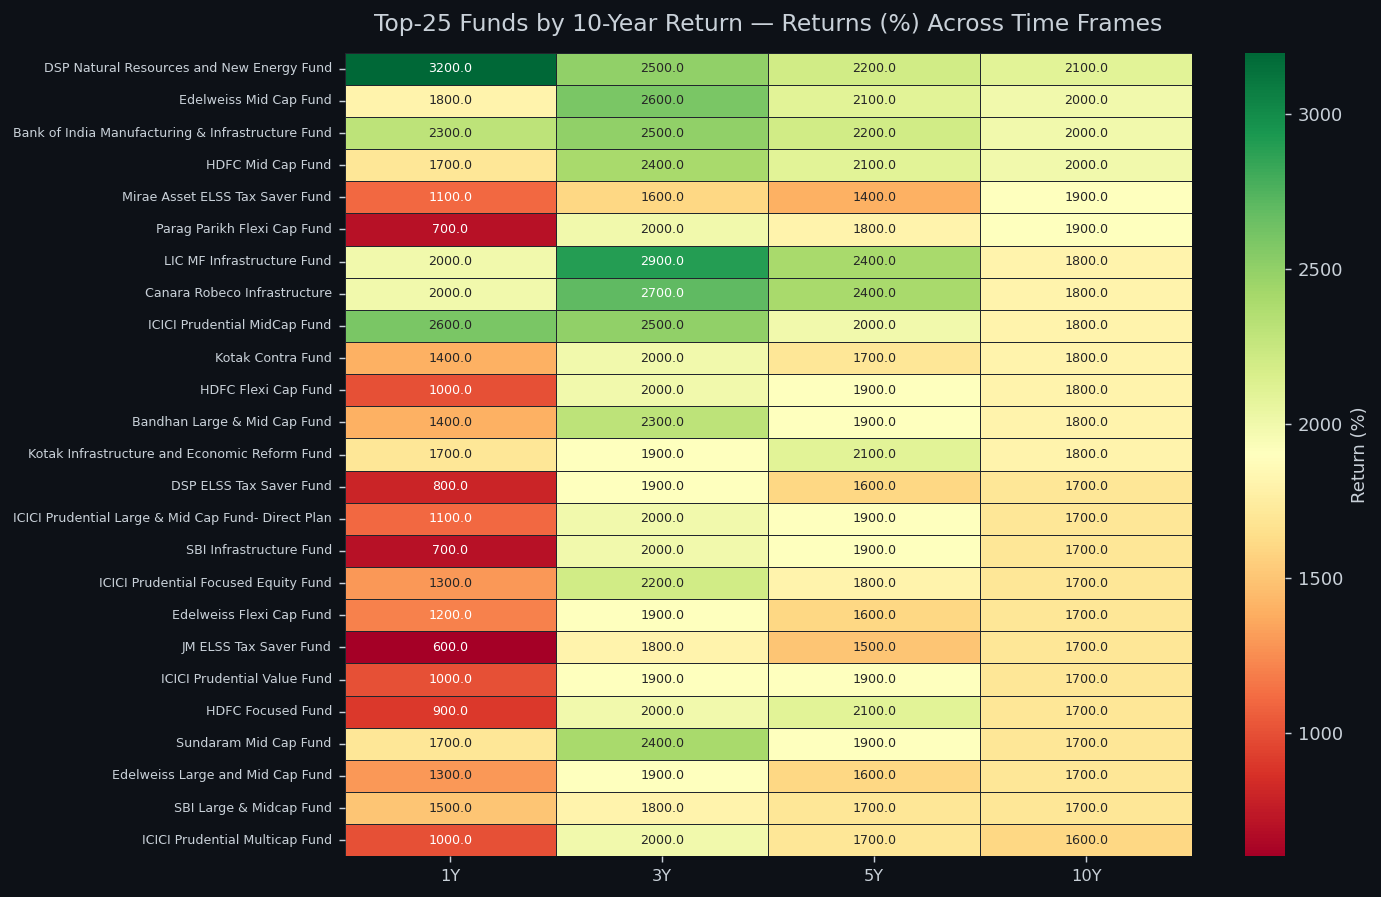


Funds in stability analysis: 46


In [13]:
# Use longer-horizon cols only — short periods (1W/1M) are noise
STABILITY_COLS = ["1Y", "3Y", "5Y", "10Y"]

sub = df[["Short Name", "Category Name", "Crisil Rating", "AuM (Cr)"] + STABILITY_COLS].copy()
sub = sub.dropna(subset=STABILITY_COLS)   # keep only funds with full history

# Returns are fractions → convert to % for readability
sub[STABILITY_COLS] = sub[STABILITY_COLS] * 100

sub["mean_return"] = sub[STABILITY_COLS].mean(axis=1)
sub["std_return"]  = sub[STABILITY_COLS].std(axis=1)
sub["CV"]          = (sub["std_return"] / sub["mean_return"].abs()) * 100

# Heatmap: top 25 by 10Y return, columns = time-frame returns
top25 = sub.nlargest(25, "10Y").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 7))
heat_data = top25.set_index("Short Name")[STABILITY_COLS]
sns.heatmap(
    heat_data,
    annot=True, fmt=".1f",
    cmap="RdYlGn",
    linewidths=0.4, linecolor="#21262d",
    ax=ax,
    annot_kws={"size": 7},
    cbar_kws={"label": "Return (%)"},
)
ax.set_title("Top-25 Funds by 10-Year Return — Returns (%) Across Time Frames", pad=12, fontsize=13)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=7)
ax.tick_params(axis="x", labelsize=9)
plt.tight_layout()
plt.show()

print(f"\nFunds in stability analysis: {len(sub)}")

## 5. Identify Top Performing Stable Funds

A **composite score** combines:
- **10-year return rank** (higher is better)
- **CV rank** (lower CV = lower rank number = better stability)

$$\text{Composite Score} = \text{Rank}_{10Y\,Return} + \text{Rank}_{CV}$$

Lower composite score → fund is both high-returning *and* stable.

In [14]:
scored = sub.copy()
scored["rank_10Y"] = scored["10Y"].rank(ascending=False)
scored["rank_CV"]  = scored["CV"].rank(ascending=True)   # low CV = good
scored["composite"] = scored["rank_10Y"] + scored["rank_CV"]
scored = scored.sort_values("composite").reset_index(drop=True)
scored.index += 1
scored.index.name = "Composite Rank"

display_cols = ["Short Name", "Category Name", "Crisil Rating", "AuM (Cr)",
                "10Y", "mean_return", "std_return", "CV", "composite"]
out = scored[display_cols].head(20).copy()
out.rename(columns={
    "10Y": "10Y Return (%)",
    "mean_return": "Mean Return (%)",
    "std_return": "StdDev (%)",
    "CV": "CV (%)",
    "composite": "Score (lower=better)",
    "AuM (Cr)": "AuM (Cr)",
}, inplace=True)
for col in ["10Y Return (%)", "Mean Return (%)", "StdDev (%)", "CV (%)"]:
    out[col] = out[col].round(2)
out["Score (lower=better)"] = out["Score (lower=better)"].round(1)
out["AuM (Cr)"] = out["AuM (Cr)"].map("{:,.0f}".format)
out

,Short Name,Category Name,Crisil Rating,AuM (Cr),10Y Return (%),Mean Return (%),StdDev (%),CV (%),Score (lower=better)
Composite Rank,,,,,,,,,
1,Bank of India Manufacturing & Infrastructure Fund,Sectoral/Thematic,5,689,2000.0,2250.0,208.17,9.25,6.0
2,HDFC Mid Cap Fund,Mid Cap Fund,4,nan,2000.0,2050.0,288.68,14.08,9.0
3,Kotak Infrastructure and Economic Reform Fund,Sectoral/Thematic,4,nan,1800.0,1875.0,170.78,9.11,12.0
4,Edelweiss Mid Cap Fund,Mid Cap Fund,5,nan,2000.0,2125.0,340.34,16.02,14.0
5,Kotak Contra Fund,Contra Fund,4,nan,1800.0,1725.0,250.00,14.49,17.0
6,DSP Natural Resources and New Energy Fund,Sectoral/Thematic,5,nan,2100.0,2500.0,496.66,19.87,18.0
7,SBI Large & Midcap Fund,Large & Mid Cap Fund,4,nan,1700.0,1675.0,125.83,7.51,20.0
8,ICICI Prudential MidCap Fund,Mid Cap Fund,4,nan,1800.0,2225.0,386.22,17.36,24.0
9,Canara Robeco Infrastructure,Sectoral/Thematic,4,934,1800.0,2225.0,403.11,18.12,25.0


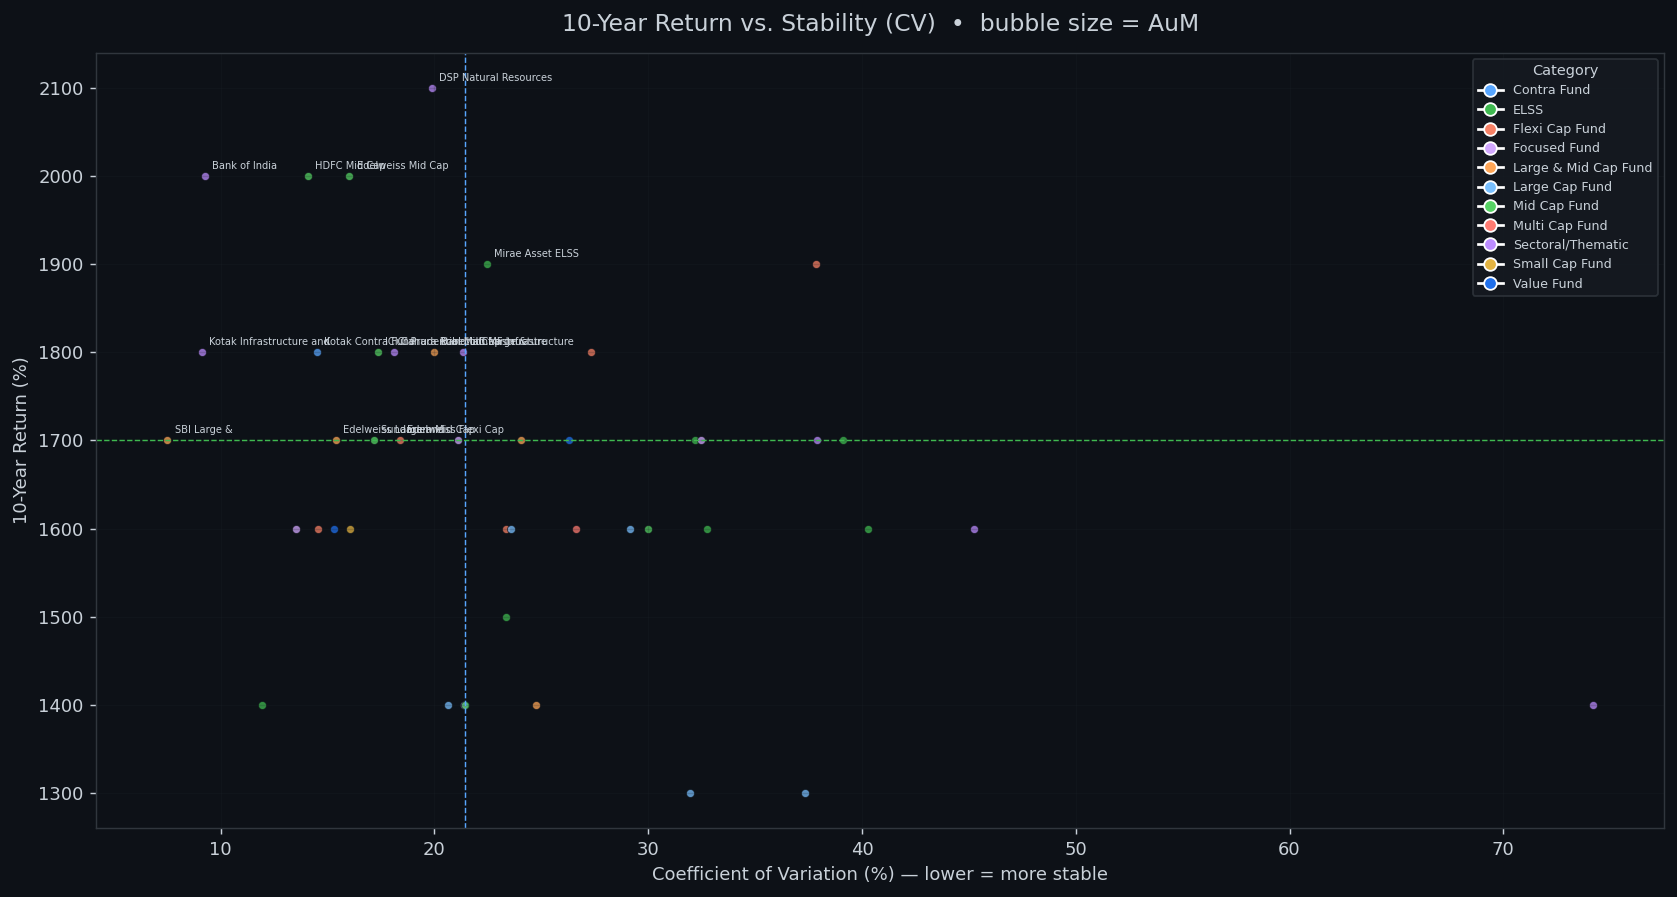

In [15]:
# ── Bubble chart: 10Y return vs CV, sized by AuM ───────────────────────────
fig, ax = plt.subplots(figsize=(13, 7))

cat_list = sorted(scored["Category Name"].unique())
cat_colors = {c: PALETTE[i % len(PALETTE)] for i, c in enumerate(cat_list)}

for _, row in scored.iterrows():
    ax.scatter(
        row["CV"], row["10Y"],
        s=max(20, row["AuM (Cr)"] / 800),
        color=cat_colors[row["Category Name"]],
        alpha=0.75, edgecolors="#0d1117", linewidth=0.5,
    )

# label top-15 composite
for _, row in scored.head(15).iterrows():
    label = row["Short Name"].split()[0:3]
    ax.annotate(
        " ".join(label),
        xy=(row["CV"], row["10Y"]),
        fontsize=5.5,
        color="#c9d1d9",
        xytext=(4, 4), textcoords="offset points",
    )

# legend for categories
handles = [
    plt.Line2D([0], [0], marker="o", color="w",
               markerfacecolor=v, markersize=7, label=k)
    for k, v in cat_colors.items()
]
ax.legend(handles=handles, title="Category", fontsize=7, title_fontsize=8,
          loc="upper right")

ax.set_xlabel("Coefficient of Variation (%) — lower = more stable", fontsize=10)
ax.set_ylabel("10-Year Return (%)", fontsize=10)
ax.set_title("10-Year Return vs. Stability (CV)  •  bubble size = AuM", fontsize=13, pad=12)
ax.axvline(scored["CV"].median(), color="#58a6ff", linestyle="--", linewidth=0.8,
           label=f"Median CV ({scored['CV'].median():.0f}%)")
ax.axhline(scored["10Y"].median(), color="#3fb950", linestyle="--", linewidth=0.8,
           label=f"Median 10Y ({scored['10Y'].median():.1f}%)")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## 6. Category-Wise Distribution Pie Chart

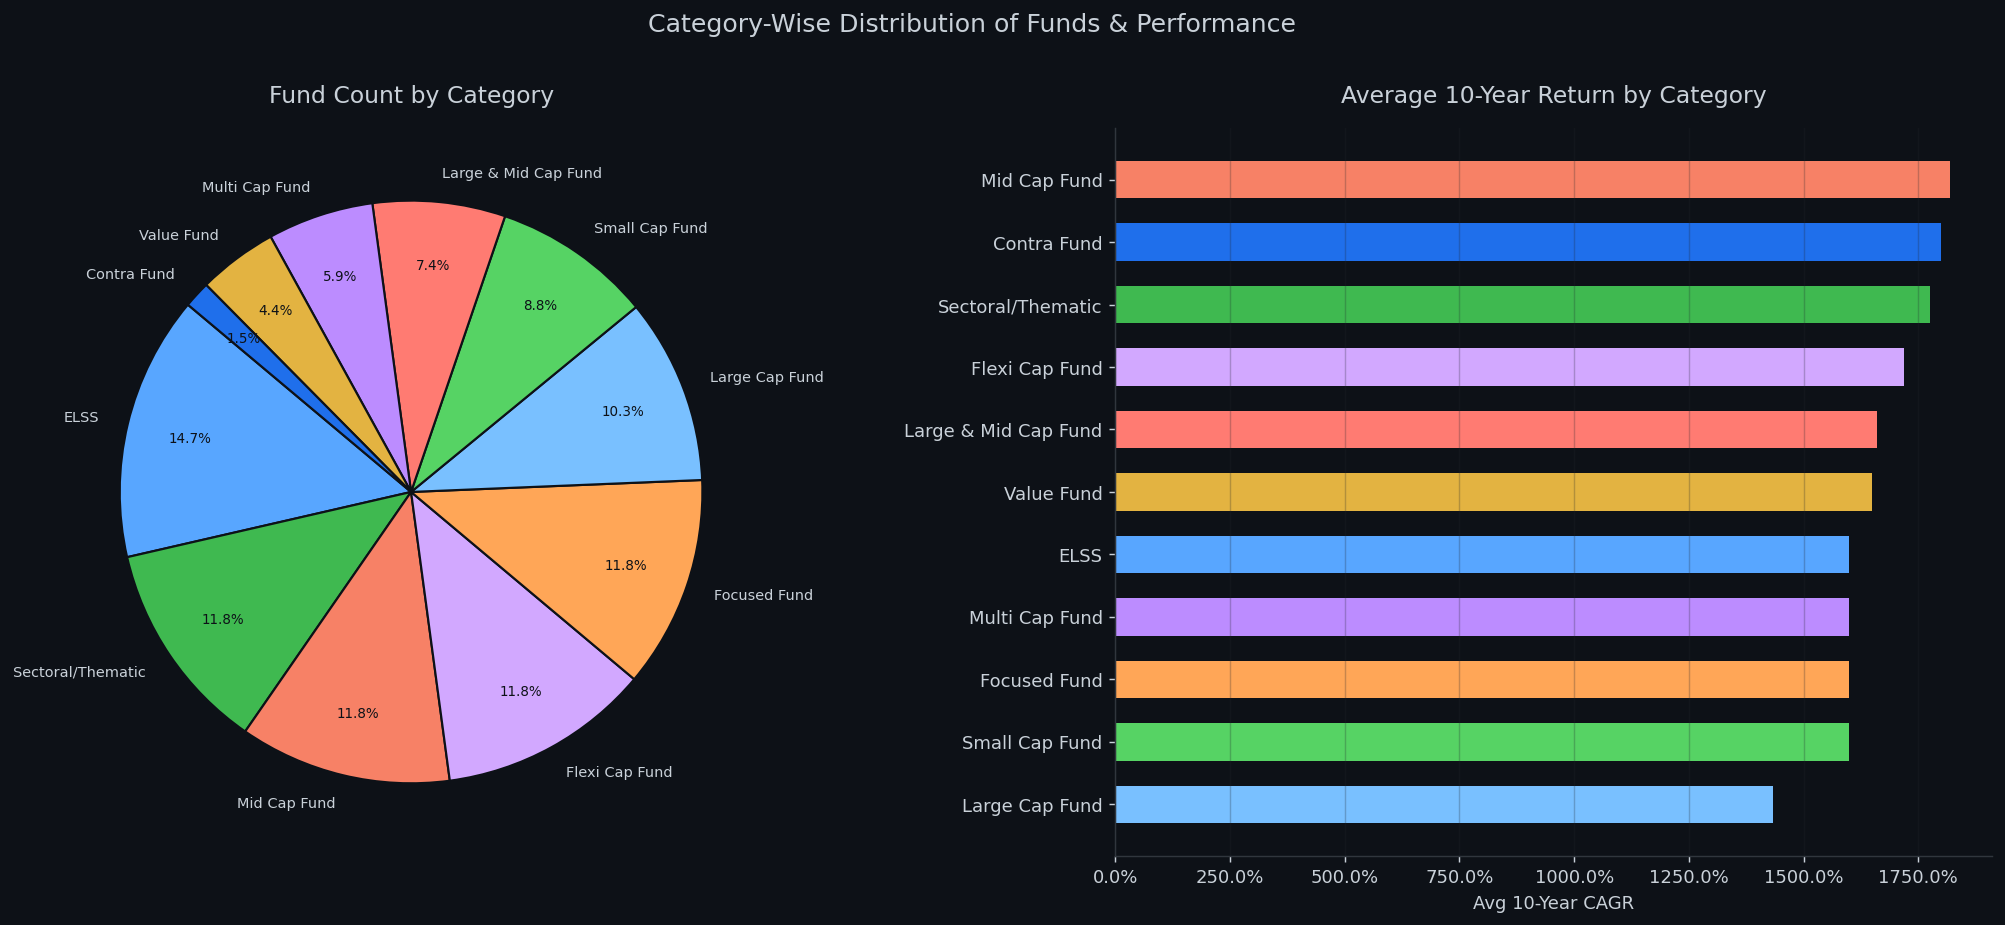

In [16]:
cat_counts = df["Category Name"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: fund count ────────────────────────────────────────────────────────
wedges, texts, autotexts = axes[0].pie(
    cat_counts,
    labels=cat_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=PALETTE[:len(cat_counts)],
    pctdistance=0.78,
    wedgeprops={"linewidth": 1.2, "edgecolor": "#0d1117"},
)
for t in texts: t.set_fontsize(8)
for at in autotexts: at.set_fontsize(7.5); at.set_color("#0d1117")
axes[0].set_title("Fund Count by Category", fontsize=13, pad=14)

# ── Right: average 10Y return per category ──────────────────────────────────
cat_10y = df.groupby("Category Name")["10Y"].mean().dropna().sort_values(ascending=False) * 100
bar_colors = [PALETTE[list(cat_counts.index).index(c) % len(PALETTE)] for c in cat_10y.index]

axes[1].barh(cat_10y.index[::-1], cat_10y.values[::-1], color=bar_colors[::-1], height=0.6)
axes[1].xaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
axes[1].set_xlabel("Avg 10-Year CAGR", fontsize=10)
axes[1].set_title("Average 10-Year Return by Category", fontsize=13, pad=14)
axes[1].grid(axis="x", alpha=0.25)
for spine in ["top", "right"]: axes[1].spines[spine].set_visible(False)

plt.suptitle("Category-Wise Distribution of Funds & Performance", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 7. Crisil Rating Distribution Pie Chart

> **Note:** The screener exports **Crisil Rank** (1–5 stars), not Morningstar ratings. Both use a 5-star scale and serve the same purpose: rating funds within their peer category on a risk-adjusted basis. Crisil 5 = top quintile.

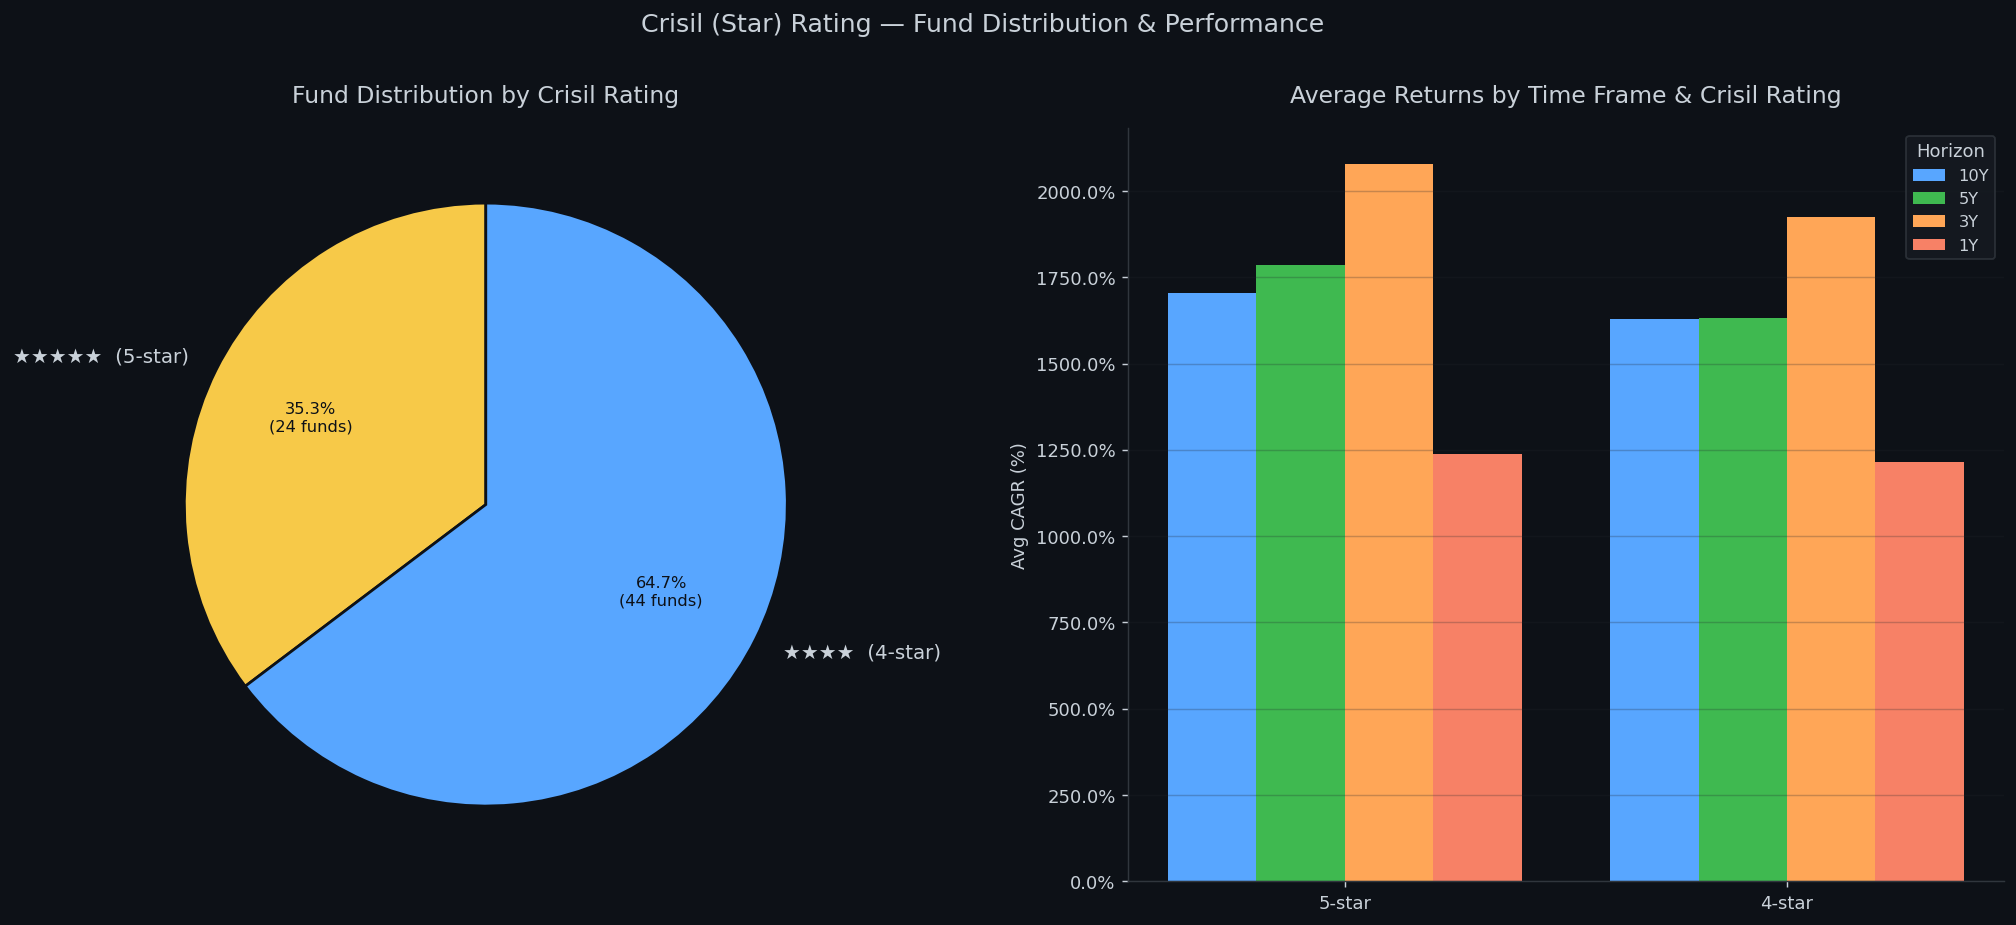

In [17]:
rating_counts = df["Crisil Rating"].value_counts().sort_index(ascending=False)
star_labels = [f"{'★' * int(r)}  ({int(r)}-star)" for r in rating_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# ── Left: pie ───────────────────────────────────────────────────────────────
star_colors = ["#f7c948", "#58a6ff"]   # gold for 5, blue for 4
wedges, texts, autotexts = axes[0].pie(
    rating_counts,
    labels=star_labels,
    autopct=lambda p: f"{p:.1f}%\n({int(round(p * len(df) / 100))} funds)",
    startangle=90,
    colors=star_colors[:len(rating_counts)],
    wedgeprops={"linewidth": 1.5, "edgecolor": "#0d1117"},
    pctdistance=0.65,
)
for t in texts: t.set_fontsize(11)
for at in autotexts: at.set_fontsize(9); at.set_color("#0d1117")
axes[0].set_title("Fund Distribution by Crisil Rating", fontsize=13, pad=14)

# ── Right: avg 10Y return per rating ────────────────────────────────────────
rating_perf = (
    df.groupby("Crisil Rating")[["10Y", "5Y", "3Y", "1Y"]]
    .mean()
    .dropna()
    .sort_index(ascending=False)
    * 100
)
x = np.arange(len(rating_perf))
width = 0.2
tf_cols  = ["10Y", "5Y", "3Y", "1Y"]
tf_colors = ["#58a6ff", "#3fb950", "#ffa657", "#f78166"]

for i, (col, col_c) in enumerate(zip(tf_cols, tf_colors)):
    axes[1].bar(x + i * width, rating_perf[col], width, label=col, color=col_c)

axes[1].set_xticks(x + width * 1.5)
axes[1].set_xticklabels([f"{int(r)}-star" for r in rating_perf.index])
axes[1].yaxis.set_major_formatter(mtick.FormatStrFormatter("%.1f%%"))
axes[1].set_ylabel("Avg CAGR (%)", fontsize=10)
axes[1].set_title("Average Returns by Time Frame & Crisil Rating", fontsize=13, pad=14)
axes[1].legend(title="Horizon", fontsize=9)
axes[1].grid(axis="y", alpha=0.25)
for spine in ["top", "right"]: axes[1].spines[spine].set_visible(False)

plt.suptitle("Crisil (Star) Rating — Fund Distribution & Performance", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 8. AUM Distribution by Category

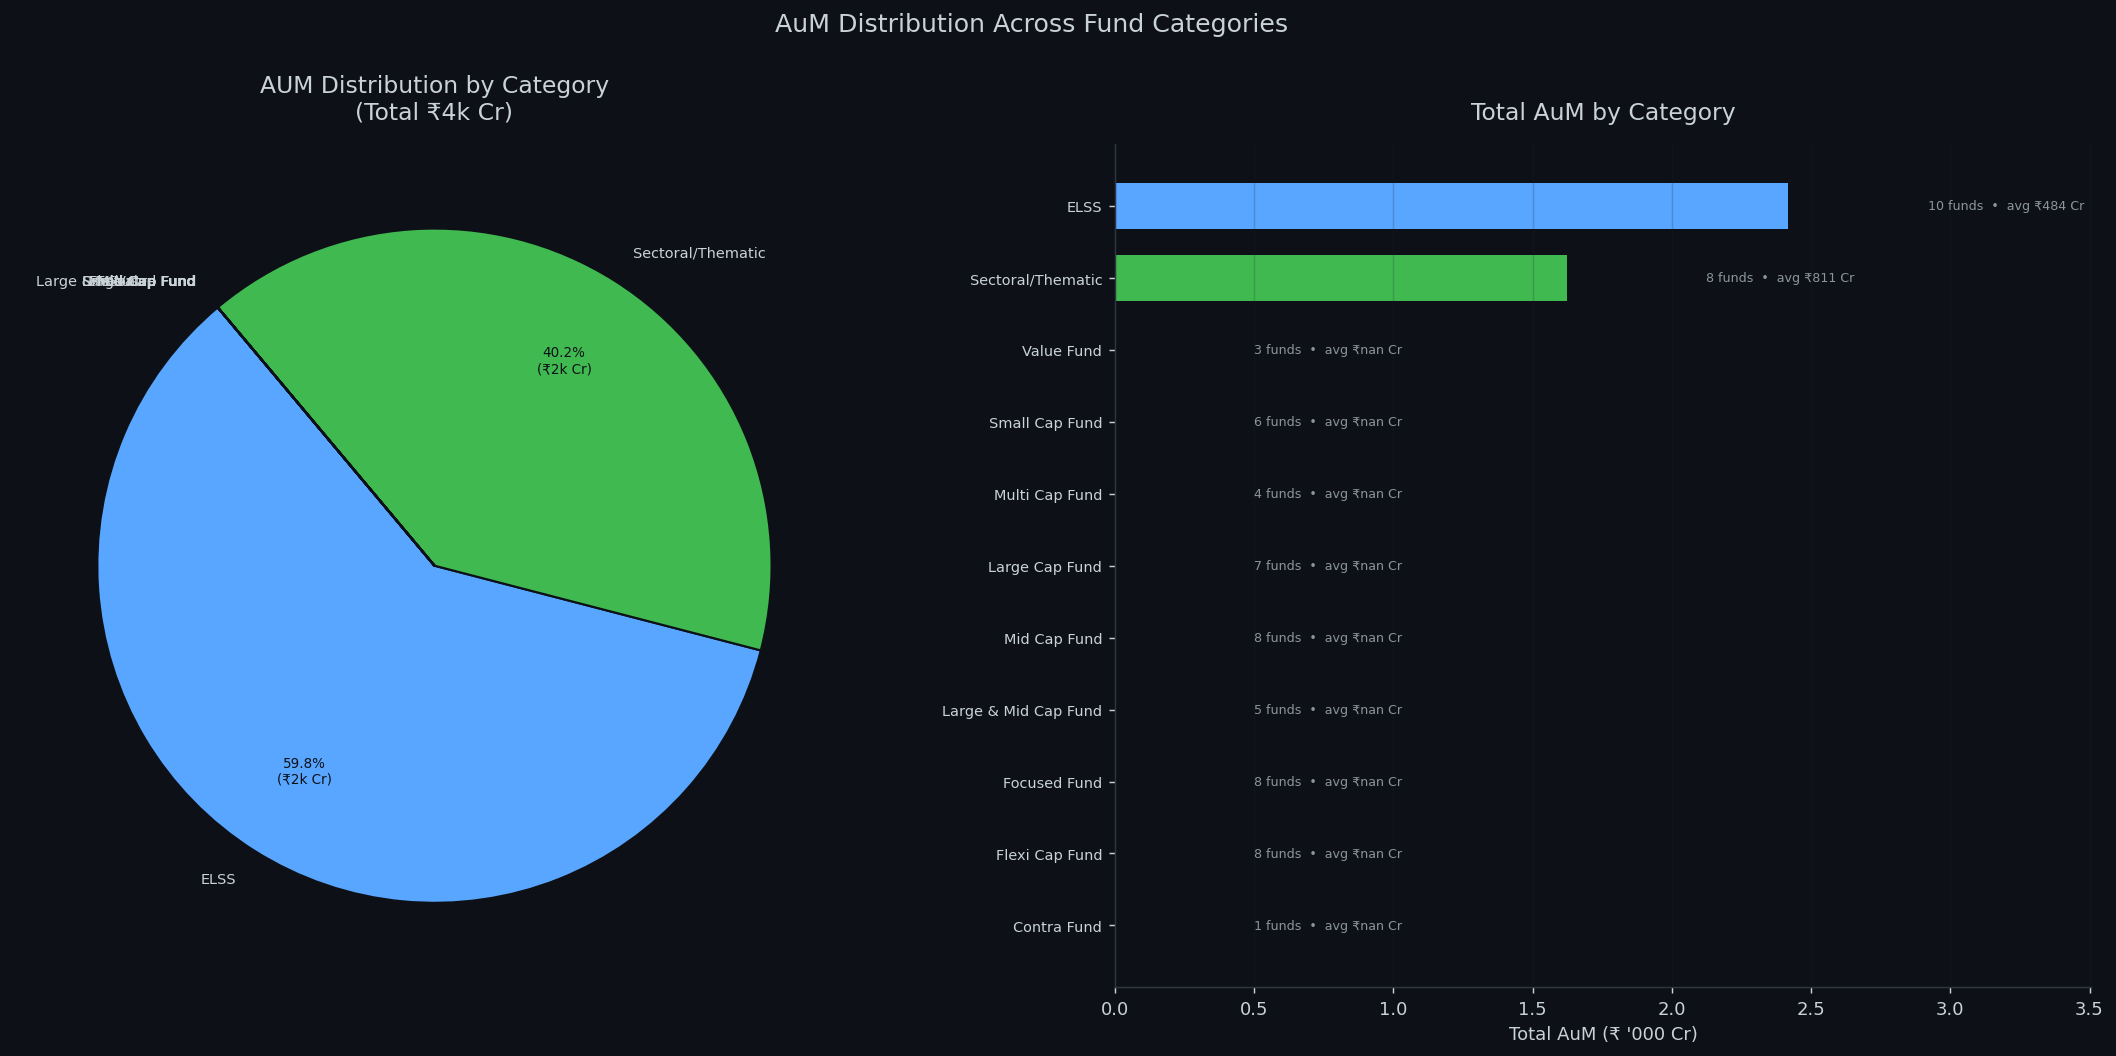


AuM summary (₹ Cr):
Category Name
ELSS                    2,419
Sectoral/Thematic       1,623
Contra Fund                 0
Flexi Cap Fund              0
Focused Fund                0
Large Cap Fund              0
Large & Mid Cap Fund        0
Mid Cap Fund                0
Multi Cap Fund              0
Small Cap Fund              0
Value Fund                  0


In [18]:
aum_by_cat = df.groupby("Category Name")["AuM (Cr)"].sum().sort_values(ascending=False)
total_aum  = aum_by_cat.sum()
aum_colors = [PALETTE[i % len(PALETTE)] for i in range(len(aum_by_cat))]

fig, axes = plt.subplots(1, 2, figsize=(17, 8))

# ── Left: AUM pie ────────────────────────────────────────────────────────────
def aum_fmt(pct):
    val = pct / 100 * total_aum
    return f"{pct:.1f}%\n(₹{val/1e3:.0f}k Cr)" if pct > 4 else ""

wedges, texts, autotexts = axes[0].pie(
    aum_by_cat,
    labels=aum_by_cat.index,
    autopct=aum_fmt,
    startangle=130,
    colors=aum_colors,
    pctdistance=0.72,
    wedgeprops={"linewidth": 1.2, "edgecolor": "#0d1117"},
)
for t in texts: t.set_fontsize(8)
for at in autotexts: at.set_fontsize(7.5); at.set_color("#0d1117")
axes[0].set_title(f"AUM Distribution by Category\n(Total ₹{total_aum/1e3:,.0f}k Cr)", fontsize=13, pad=14)

# ── Right: stacked bar — fund count & avg AuM per fund ───────────────────────
cat_stats = df.groupby("Category Name").agg(
    fund_count=("Scheme Name", "count"),
    avg_aum=("AuM (Cr)", "mean"),
    total_aum=("AuM (Cr)", "sum"),
).sort_values("total_aum", ascending=True)

y_pos = np.arange(len(cat_stats))
bar_c = [PALETTE[list(aum_by_cat.index).index(c) % len(PALETTE)] for c in cat_stats.index]

bars = axes[1].barh(y_pos, cat_stats["total_aum"] / 1e3, color=bar_c, height=0.65)
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(cat_stats.index, fontsize=8)
axes[1].set_xlabel("Total AuM (₹ '000 Cr)", fontsize=10)
axes[1].set_title("Total AuM by Category", fontsize=13, pad=14)

# annotate fund count
for bar, (_, row) in zip(bars, cat_stats.iterrows()):
    axes[1].text(
        bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
        f"{int(row['fund_count'])} funds  •  avg ₹{row['avg_aum']:,.0f} Cr",
        va="center", fontsize=7, color="#8b949e",
    )

axes[1].grid(axis="x", alpha=0.2)
for spine in ["top", "right"]: axes[1].spines[spine].set_visible(False)
axes[1].set_xlim(0, cat_stats["total_aum"].max() / 1e3 * 1.45)

plt.suptitle("AuM Distribution Across Fund Categories", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("\nAuM summary (₹ Cr):")
print(aum_by_cat.map("{:,.0f}".format).to_string())